# Real Estate Exploratory Data Analysis
This notebook performs basic Exploratory Data Analysis (EDA) on three key datasets:
- `buildings_clean.csv`
- `transactions_clean.csv`
- `valuations_clean.csv`

The goal is to understand the structure of the data, find missing patterns, and visualize key distributions to aid in buying decisions.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Set display options to view all columns
pd.set_option('display.max_columns', None)

## 1. Load Data

In [21]:
# Load datasets
buildings = pd.read_csv('data/buildings_clean.csv')
df_buildings = buildings.copy()
transactions = pd.read_csv('data/transactions_clean.csv')
df_transactions = transactions.copy()   
valuations = pd.read_csv('data/valuations_clean.csv')
df_valuations = valuations.copy()

## 2. Basic Information and Summaries

In [10]:
print("Buildings dataset shape:", buildings.shape)
display(buildings.head())
buildings.info()

Buildings dataset shape: (3173, 27)


,Property Sub Type,Property Size (sq.m),Common Area,Actual Common Area,Built Up Area,Buidling Levels,Shops,Flats,Offices,Swimming Pools,Elevators,Creation Date,Registration type,Pre registration Number,Is Free Hold?,Is Lease Hold,Floors,Room(s),Parking,Land Number,Land Sub Number,Land Type,Master Project,Project Number,Project Name,Area,Zone
0,Building,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-01 11:11:37,Ready,NaN,Free Hold,Yes,NaN,NaN,NaN,1058,0.0,Industrial,NaN,NaN,NaN,Jabal Ali Industrial First,Dubai
1,Building,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-28 10:15:15,Ready,NaN,Free Hold,No,NaN,NaN,NaN,205,0.0,NaN,NaN,NaN,NaN,Warsan Fourth,Dubai
2,Building,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-06 10:17:27,Ready,NaN,Free Hold,No,NaN,NaN,NaN,288,0.0,Industrial,NaN,NaN,NaN,Saih Shuaib 4,Dubai
3,Building,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-02-10 07:51:59,Ready,NaN,Free Hold,No,NaN,NaN,NaN,775,0.0,Industrial,NaN,NaN,NaN,Saih Shuaib 4,Dubai
4,Building,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-03 09:07:34,Ready,NaN,Free Hold,No,NaN,NaN,NaN,3695,0.0,Commercial,NaN,NaN,NaN,Al Satwa,Dubai


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property Sub Type        3173 non-null   object 
 1   Property Size (sq.m)     3173 non-null   float64
 2   Common Area              3112 non-null   float64
 3   Actual Common Area       3112 non-null   float64
 4   Built Up Area            3173 non-null   float64
 5   Buidling Levels          6 non-null      float64
 6   Shops                    0 non-null      float64
 7   Flats                    0 non-null      float64
 8   Offices                  0 non-null      float64
 9   Swimming Pools           0 non-null      float64
 10  Elevators                0 non-null      float64
 11  Creation Date            3173 non-null   object 
 12  Registration type        3173 non-null   object 
 13  Pre registration Number  0 non-null      float64
 14  Is Free Hold?           

In [ ]:
print(buildings.duplicated().sum())

806


In [20]:
duplicates = buildings[buildings.duplicated(keep=False)]
duplicates

,Property Sub Type,Property Size (sq.m),Common Area,Actual Common Area,Built Up Area,Buidling Levels,Shops,Flats,Offices,Swimming Pools,Elevators,Creation Date,Registration type,Pre registration Number,Is Free Hold?,Is Lease Hold,Floors,Room(s),Parking,Land Number,Land Sub Number,Land Type,Master Project,Project Number,Project Name,Area,Zone
52,Villa,103.50,0.32,45.80,129.77,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07 09:32:08,Off-Plan,NaN,Free Hold,Yes,2.0,2 B/R,1.0,12,0.0,Commercial,NaN,4288.0,Verdana 6,Dubai Investment Park First,Dubai
53,Villa,106.78,0.33,47.25,129.77,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07 09:32:14,Off-Plan,NaN,Free Hold,Yes,2.0,2 B/R,1.0,12,0.0,Commercial,NaN,4288.0,Verdana 6,Dubai Investment Park First,Dubai
55,Villa,99.00,0.62,47.59,269.19,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07 09:36:49,Off-Plan,NaN,Free Hold,Yes,4.0,4 B/R,1.0,23,0.0,Commercial,NaN,4257.0,Verdana 10,Dubai Investment Park First,Dubai
60,Villa,99.22,0.66,48.64,129.78,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-20 14:59:02,Off-Plan,NaN,Free Hold,Yes,2.0,2 B/R,1.0,17,0.0,Commercial,NaN,3302.0,Verdana 3,Dubai Investment Park First,Dubai
62,Villa,99.00,0.28,53.51,129.78,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-07 17:43:03,Off-Plan,NaN,Free Hold,Yes,2.0,2 B/R,1.0,11,0.0,Commercial,NaN,4289.0,Verdana 7,Dubai Investment Park First,Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3165,Villa,144.00,0.17,138.17,205.36,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:39:19,Off-Plan,NaN,Free Hold,No,2.0,4 B/R,2.0,21638,NaN,NaN,NaN,4369.0,DAMAC ISLANDS 2 - ANTIGUA 1,Al Yelayiss 1,Dubai
3166,Villa,144.00,0.17,138.17,205.36,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:39:17,Off-Plan,NaN,Free Hold,No,2.0,4 B/R,2.0,21627,NaN,NaN,NaN,4369.0,DAMAC ISLANDS 2 - ANTIGUA 1,Al Yelayiss 1,Dubai
3169,Villa,144.00,0.17,138.17,205.36,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:39:15,Off-Plan,NaN,Free Hold,No,2.0,4 B/R,2.0,21615,NaN,NaN,NaN,4369.0,DAMAC ISLANDS 2 - ANTIGUA 1,Al Yelayiss 1,Dubai
3170,Villa,144.00,0.17,138.17,265.16,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-29 12:39:23,Off-Plan,NaN,Free Hold,No,3.0,5 B/R,2.0,21656,NaN,NaN,NaN,4369.0,DAMAC ISLANDS 2 - ANTIGUA 1,Al Yelayiss 1,Dubai


In [22]:
df_1 = buildings.drop_duplicates()

In [23]:
df_1.shape

(2367, 27)

In [24]:
print(df_1.duplicated().sum())

0


In [25]:
df_1.nunique()

Property Sub Type             3
Property Size (sq.m)       1542
Common Area                 151
Actual Common Area         1438
Built Up Area               156
Buidling Levels               1
Shops                         0
Flats                         0
Offices                       0
Swimming Pools                0
Elevators                     0
Creation Date               184
Registration type             2
Pre registration Number       0
Is Free Hold?                 1
Is Lease Hold                 2
Floors                        3
Room(s)                       8
Parking                      10
Land Number                 726
Land Sub Number               1
Land Type                     5
Master Project                0
Project Number               23
Project Name                 23
Area                         32
Zone                          2
dtype: int64

In [26]:
df_1.dtypes

Property Sub Type           object
Property Size (sq.m)       float64
Common Area                float64
Actual Common Area         float64
Built Up Area              float64
Buidling Levels            float64
Shops                      float64
Flats                      float64
Offices                    float64
Swimming Pools             float64
Elevators                  float64
Creation Date               object
Registration type           object
Pre registration Number    float64
Is Free Hold?               object
Is Lease Hold               object
Floors                     float64
Room(s)                     object
Parking                    float64
Land Number                  int64
Land Sub Number            float64
Land Type                   object
Master Project             float64
Project Number             float64
Project Name                object
Area                        object
Zone                        object
dtype: object

In [27]:
print("Transactions dataset shape:", transactions.shape)
display(transactions.head())
transactions.info()

Transactions dataset shape: (45308, 22)


,Transaction Number,Transaction Date,Transaction Type,Transaction sub type,Registration type,Is Free Hold?,Usage,Area,Property Type,Property Sub Type,Amount,Transaction Size (sq.m),Property Size (sq.m),Room(s),Parking,Nearest Metro,Nearest Mall,Nearest Landmark,No. of Buyer,No. of Seller,Master Project,Project
0,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,15925000.0,284.65,284.65,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
1,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,15925000.0,572.59,572.59,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
2,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,15925000.0,509.08,509.08,4 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
3,101-2-2026,2026-01-29 18:04:38,Mortgage,Portfolio Mortgage Registration Pre-Registration,Off-Plan,Free Hold,Residential,BUSINESS BAY,Unit,Flat,15925000.0,261.39,261.39,3 B/R,2,Buj Khalifa Dubai Mall Metro Station,Dubai Mall,Downtown Dubai,0,0,NaN,THE CRESTMARK
4,102-1-2026,2026-01-01 16:21:33,Sales,Sell - Pre registration,Off-Plan,Free Hold,Residential,Jabal Ali First,Unit,Flat,1099573.0,72.41,72.41,1 B/R,1,ENERGY Metro Station,Ibn-e-Battuta Mall,Expo 2020 Site,0,0,NaN,Hills View at Wasl Gate


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45308 entries, 0 to 45307
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transaction Number       45308 non-null  object 
 1   Transaction Date         45308 non-null  object 
 2   Transaction Type         45308 non-null  object 
 3   Transaction sub type     45308 non-null  object 
 4   Registration type        45308 non-null  object 
 5   Is Free Hold?            45308 non-null  object 
 6   Usage                    45308 non-null  object 
 7   Area                     45308 non-null  object 
 8   Property Type            45308 non-null  object 
 9   Property Sub Type        44571 non-null  object 
 10  Amount                   45308 non-null  float64
 11  Transaction Size (sq.m)  45307 non-null  float64
 12  Property Size (sq.m)     45308 non-null  float64
 13  Room(s)                  38286 non-null  object 
 14  Parking               

In [5]:
print("Valuations dataset shape:", valuations.shape)
display(valuations.head())
valuations.info()

Valuations dataset shape: (1109, 10)


,Property Total Value,Area,Property Size (sq.m),Procedure Year,Procedure Number,Transaction Date,Amount,Transaction Size (sq.m),Property Type,Property Sub Type
0,629,Al Murqabat,629.55,2026,1362,2026-03-03 12:41:50,629.0,629.55,Land,Commercial
1,2274,Hor Al Anz,211.35,2026,1363,2026-03-03 13:13:16,2274.0,211.35,Land,Residential
2,2499,Abu Hail,232.21,2026,219,2026-01-09 09:38:53,2499.0,232.21,Land,Residential
3,33454,Al Hebiah Fourth,3108.07,2026,1358,2026-03-03 11:14:38,33454.0,3108.07,Land,Residential Flats
4,54024,Saih Shuaib 2,16.73,2026,831,2026-02-05 11:04:42,54024.0,16.73,Land,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property Total Value     1109 non-null   int64  
 1   Area                     1109 non-null   object 
 2   Property Size (sq.m)     1109 non-null   float64
 3   Procedure Year           1109 non-null   int64  
 4   Procedure Number         1109 non-null   int64  
 5   Transaction Date         1109 non-null   object 
 6   Amount                   1109 non-null   float64
 7   Transaction Size (sq.m)  1109 non-null   float64
 8   Property Type            1109 non-null   object 
 9   Property Sub Type        1038 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 86.8+ KB


## 3. Data Cleaning / Conversions
We need to ensure date columns are in datetime format to allow time-series analysis.

In [28]:
# Convert Transaction Dates to datetime
if 'Transaction Date' in transactions.columns:
    transactions['Transaction Date'] = pd.to_datetime(transactions['Transaction Date'], errors='coerce')

if 'Transaction Date' in valuations.columns:
    valuations['Transaction Date'] = pd.to_datetime(valuations['Transaction Date'], errors='coerce')

if 'Creation Date' in buildings.columns:
    buildings['Creation Date'] = pd.to_datetime(buildings['Creation Date'], errors='coerce')

/tmp/ipykernel_16224/130228660.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_areas.index, x=top_areas.values, palette='viridis')


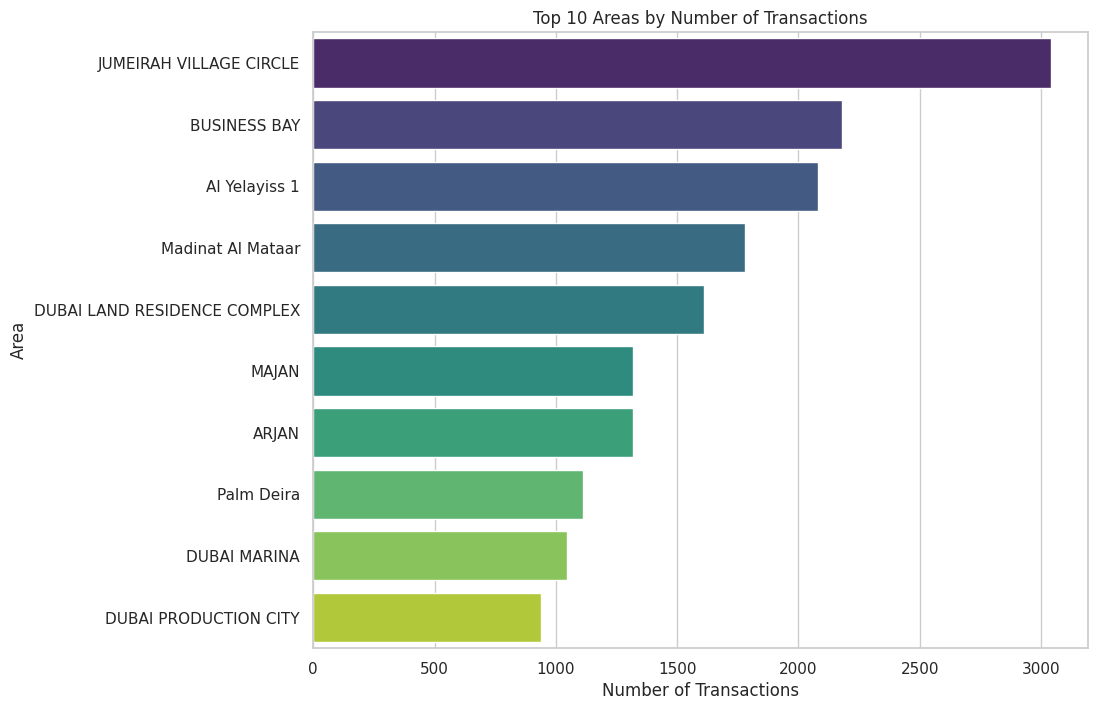

In [33]:
# Example 2: Most Popular Areas for Buying (from Transactions)
plt.figure(figsize=(10, 8))
top_areas = transactions['Area'].value_counts().head(10)
sns.barplot(y=top_areas.index, x=top_areas.values, palette='viridis')
plt.title('Top 10 Areas by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Area')
plt.show()

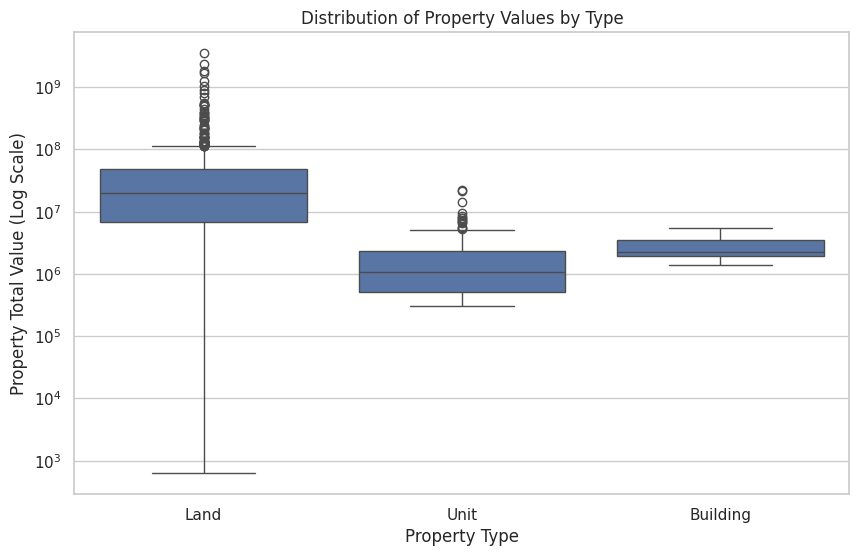

In [34]:
# Example 3: Compare Property Types against Valuations
plt.figure(figsize=(10, 6))
sns.boxplot(data=valuations, x='Property Type', y='Property Total Value')
plt.title('Distribution of Property Values by Type')
plt.yscale('log') # Use log scale because property values can vary wildly
plt.xlabel('Property Type')
plt.ylabel('Property Total Value (Log Scale)')
plt.show()

## 5. Merging Strategy Example
Merging `transactions` and `valuations` based on `Area` and `Property Type` can help find bargains where transaction prices are systematically lower than valuations.

In [32]:
# Group by Area and Property Type
avg_trans = transactions.groupby(['Area', 'Property Type'])['Amount'].mean().reset_index(name='Avg_Trans_Amount')
avg_val = valuations.groupby(['Area', 'Property Type'])['Property Total Value'].mean().reset_index(name='Avg_Valuation')

# Merge aggregated data
area_comparison = pd.merge(avg_trans, avg_val, on=['Area', 'Property Type'], how='inner')

# Calculate difference (% difference)
area_comparison['Profit_%'] = ((area_comparison['Avg_Valuation'] - area_comparison['Avg_Trans_Amount']) / area_comparison['Avg_Trans_Amount']) * 100

print("Top 5 areas with the highest potential profit %:")
display(area_comparison.sort_values(by='Profit_%', ascending=False))


Top 5 areas where actual transactions are cheaper than valuations:


,Area,Property Type,Avg_Trans_Amount,Avg_Valuation,Undervalued_%
108,Mushrif,Land,1.200000e+06,1.049698e+09,99.885681
137,Wadi Al Safa 4,Land,6.284350e+05,1.107871e+08,99.432754
77,Dubai Investment Park First,Land,3.483325e+06,4.374293e+08,99.203683
132,Wadi Al Amardi,Land,1.079902e+06,9.111384e+07,98.814778
90,Jumeirah Second,Land,2.000000e+06,1.345280e+08,98.513320
...,...,...,...,...,...
70,Al Yelayiss 1,Land,7.486936e+07,1.125061e+07,-565.469492
99,Marsa Dubai,Land,1.750000e+09,1.334930e+08,-1210.930407
52,Al Rowaiyah First,Land,1.267647e+09,4.589682e+07,-2661.949346
73,Al Yufrah 1,Land,7.991152e+06,1.051360e+05,-7500.775928


### Visualizing Areas with Highest Potential Profit
Let's create a bar chart to easily see the top areas with the highest potential profit % and their property types.

In [ ]:
plt.figure(figsize=(12, 8))
top_profitable = area_comparison.sort_values(by='Profit_%', ascending=False).head(15)

# Create a bar plot
sns.barplot(data=top_profitable, x='Profit_%', y='Area', hue='Property Type', dodge=False, palette='viridis')
plt.title('Top 15 Areas with Highest Potential Profit %')
plt.xlabel('Potential Profit (%)')
plt.ylabel('Area')
plt.legend(title='Property Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [35]:
area_comparison

,Area,Property Type,Avg_Trans_Amount,Avg_Valuation,Undervalued_%
0,AL MIZHAR FOURTH,Land,4.909592e+05,2.200000e+06,77.683674
1,AL TWAR FIFTH,Land,1.290000e+07,5.443892e+07,76.303720
2,Abu Hail,Land,2.677040e+06,3.275318e+06,18.266252
3,Al Aweer First,Land,1.254199e+06,2.297051e+07,94.539957
4,Al Aweer Second,Land,1.960137e+06,4.000000e+06,50.996575
...,...,...,...,...,...
141,Wadi Al Safa 5,Unit,2.358148e+06,8.203600e+05,-187.452851
142,Wadi Al Safa 7,Building,1.254768e+06,2.327866e+06,46.097931
143,Wadi Al Safa 7,Land,9.066724e+06,4.993266e+06,-81.579033
144,Warsan Fourth,Land,1.321943e+07,1.805327e+07,26.775443


## 6. Predictive Machine Learning Model
We will train a model to predict the missing transaction `Amount` based on property features using a Random Forest Regressor.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Focus purely on transactions for price prediction
ml_data = transactions[['Amount', 'Property Size (sq.m)', 'Area', 'Property Type', 'Room(s)']].copy()

# Drop rows with missing values
ml_data = ml_data.dropna()

# Encode categorical variables
le_area = LabelEncoder()
le_type = LabelEncoder()
le_rooms = LabelEncoder()

ml_data['Area_Encoded'] = le_area.fit_transform(ml_data['Area'])
ml_data['Type_Encoded'] = le_type.fit_transform(ml_data['Property Type'])
ml_data['Rooms_Encoded'] = le_rooms.fit_transform(ml_data['Room(s)'])

# Features and Target
X = ml_data[['Property Size (sq.m)', 'Area_Encoded', 'Type_Encoded', 'Rooms_Encoded']]
y = ml_data['Amount']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")


In [ ]:
# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:,.2f}")
print(f"R^2 Score: {r2:.4f}")


In [ ]:
# Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, palette='magma')
plt.title('Feature Importances in Predicting Property Price')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
